In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import urllib.request

df = pd.read_csv('bio-pathways-network.csv')

edges = list(zip(df['Gene ID 1'], df['Gene ID 2']))

G_human = nx.Graph()
G_human.add_edges_from(edges)

print("Human nodes:", len(G_human.nodes()), "edges:", len(G_human.edges()))

urllib.request.urlretrieve(
    'http://snap.stanford.edu/deepnetbio-ismb/ipynb/yeast.edgelist',
    'yeast.edgelist'
)
yeast_file = "yeast.edgelist"
G_yeast = nx.read_edgelist(yeast_file)

print("Yeast nodes:", len(G_yeast.nodes()), "edges:", len(G_yeast.edges()))

Human nodes: 21557 edges: 342353
Yeast nodes: 6526 edges: 532180


In [2]:
from networkx.algorithms.community import modularity
from networkx.utils import py_random_state

For networkx library's louvain algorithm, the threshold parameter determines the modularity gain threshold per level. If the gain of modularity between two levels is lower than the threshold, the algorithm stops and returns resulting communities.

Hence, I shall use a range of threshold values for each dataset. The threshold value that produces the best results shall be used as the final community detection result for each dataset.

This shall be judged based on silhouette, Calinski Harabasz index, Davies Bouldin Index and Noise Ratio

Yeast Community Detection

Total number of classes/clusters not given for the yeast ppi. Hence, resolution and max_level parameters remain at their default values of 1 and None respectively.

The threshold value shall start from 0 and increase at increments of 0.1 until it reaches 1/doesn't increase anymore

In [3]:
yeast_grps = nx.community.louvain_communities(G_yeast, seed=42)
print(len(yeast_grps))

for community in yeast_grps:
    print(community)
    print('\n')

6
{'RP11-452K12.9', 'YIL149C', 'tS(GCU)O', 'YKR038C', 'YDR210C-C', 'YDR447C', 'YHR193C', 'YDR500C', 'YMR260C', 'YLR435W', 'YGR054W', 'YDR312W', 'YKR063C', 'tR(UCU)M1', 'YBR025C', 'RP4-669K10.2', 'YCR072C', 'YDR299W', 'YHR141C', 'YPL009C', 'YCR047C', 'YLR029C', 'YDL014W', 'RP11-318L16.1', 'YCL031C', 'YGR162W', 'YHR023W', '-', 'YBR249C', 'YPL143W', 'DAAP-218M18.2', 'YPL043W', 'YDR418W', 'YKR043C', 'RP4-769N13.4', 'YGL078C', 'YPR144C', 'YMR302C', 'YOL047C', 'YOR310C', 'YPL245W', 'tL(UAA)L', 'YLR051C', 'YCL034W', 'YGL105W', 'snR37', 'OK/SW-cl.85', 'YKR024C', 'YPL037C', 'YJR094W-A', 'YNL268W', 'YDL136W', 'YPR200C', 'YER063W', 'YML111W', 'YNL004W', 'YNL207W', 'YKL009W', 'YOR145C', 'YMR012W', 'YLR129W', 'YDR385W', 'YNL069C', 'snR17a', 'RP11-129O7.1', 'YBL087C', 'YGL120C', 'YGR204W', 'YPL160W', 'YGL246C', 'YDL055C', 'YOR091W', 'YER007C-A', 'YPR129W', 'YNL140C', 'YJL080C', 'YLR035C-A', 'YNL054W-B', 'YHR072W-A', 'YEL033W', 'YBR034C', 'snR81', 'YGR134W', 'YAR010C', 'YDR261C-D', 'YDR450W', 'YOR078

Yeast Cluster Distribution

The graph below shows a greatly uneven distribution of yeast nodes between clusters

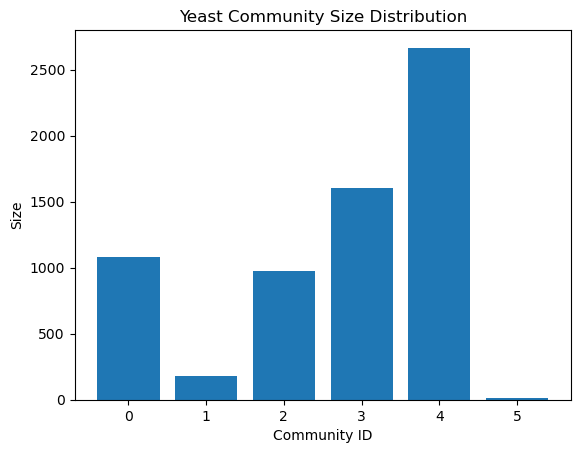

In [4]:
yeast_df = pd.DataFrame()
yeast_df['Community ID'] = range(len(yeast_grps))
yeast_df['Members'] = None

for idx, community in enumerate(yeast_grps):
    yeast_df.at[idx, 'Members'] = list(community)
    yeast_df.at[idx, 'Size'] = len(community)

plt.bar(yeast_df['Community ID'], yeast_df['Size'])
plt.xlabel('Community ID')
plt.ylabel('Size')
plt.title('Yeast Community Size Distribution')
plt.show()


Human Community Detection

Number of diseases/clusters for this dataset is 519. Hence the resolution parameter is used. For default threshold value of 0.0000001, the resolution is 13.25295

The threshold value shall increment in the same manner as the yeast, but the resolution parameter will change accordingly to ensure the number of clusters remain at 519.

In [5]:
human_grps = nx.community.louvain_communities(G_human, resolution=13.25295, seed=42)
print(len(human_grps))

519


Checking accuracy of communities matched 

In [7]:
human_df = pd.read_csv('bio-pathways-associations.csv')

human_df['Matched Community'] = None
human_df['Percentage Match'] = 0.0

for community in human_grps:
    community_set = set(community)
    for idx, row in human_df.iterrows():
        gene_set = set(map(int ,row['Associated Gene IDs'].split(', ')))
        intersection = community_set.intersection(gene_set)
        if len(intersection) > 0:
            percentage_match = len(intersection) / len(gene_set) * 100
            if percentage_match > row['Percentage Match']:
                human_df.at[idx, 'Matched Community'] = community
                human_df.at[idx, 'Percentage Match'] = percentage_match

human_df.to_csv('bio-pathways-associations-with-communities.csv', index=False)
human_df.head(10)

,Disease ID,Disease Name,Associated Gene IDs,Matched Community,Percentage Match
0,C0036095,Salivary Gland Neoplasms,"1462, 1612, 182, 2011, 2019, 2175, 2195, 23209...","{55808, 8704, 728577, 79369, 83468, 8720, 8722...",8.888889
1,C0033941,"Psychoses, Substance-Induced","135, 1636, 207, 2099, 2912, 2950, 3350, 3362, ...","{152579, 2054, 2055, 51208, 11270, 7180, 23566...",11.764706
2,C0043459,Zellweger Syndrome,"3295, 5189, 5190, 5192, 5193, 5194, 5195, 5567...","{5824, 11264, 5825, 373509, 5192, 5193, 201164...",33.333333
3,C0033860,Psoriasis,"100271719, 10318, 10498, 10547, 10758, 10866, ...","{307200, 3589, 3590, 2057, 3596, 3597, 3598, 5...",6.250000
4,C0027726,Nephrotic Syndrome,"1277, 1282, 1284, 2, 213, 2152, 2247, 2262, 29...","{4099, 714, 3082, 3083, 12, 5648, 5653, 6678, ...",23.809524
5,C0338480,Common Migraine,"221692, 23063, 23245, 338342, 4035, 4209, 6863...","{57600, 60673, 9474, 115201, 67841, 2565, 2570...",8.333333
6,C0026636,Mouth Diseases,"10036, 2189, 2937, 3301, 51182, 54541, 56603, ...","{5890, 51460, 8968, 474382, 41743, 8208, 51230...",16.666667
7,C1838979,MITOCHONDRIAL COMPLEX I DEFICIENCY,"126328, 137682, 25915, 29078, 374291, 4535, 45...","{1537, 133121, 4358, 54539, 125965, 374291, 79...",82.142857
8,C0236969,Substance-Related Disorders,"1012, 10160, 10207, 10257, 105, 1080, 11278, 1...","{2560, 2561, 2562, 2566, 147463, 57863, 2567, ...",4.385965
9,C0002878,"Anemia, Hemolytic","2056, 2539, 2729, 2821, 2936, 3043, 3162, 3440...","{10753, 5634, 5635, 5636, 2821, 6675, 2582, 10...",16.666667


The below statistics show the extent each community was matched correctly by Louvain Algorithm

The maximum percentage match is only 85% and the median and average percentage match are very low, hence Louvain algorithm is not accurate at precise identification of a large number of communities

In [8]:
#max percentage match
max_match = human_df['Percentage Match'].max()
print(f'Maximum Percentage Match: {max_match}%')

#min percentage match
min_match = human_df['Percentage Match'].min()
print(f'Minimum Percentage Match: {min_match}%')

#median percentage match
median_match = human_df['Percentage Match'].median()
print(f'Median Percentage Match: {median_match}%')

#average percentage match
avg_match = human_df['Percentage Match'].mean()
print(f'Average Percentage Match: {avg_match}%')

Maximum Percentage Match: 85.0%
Minimum Percentage Match: 2.2222222222222223%
Median Percentage Match: 10.0%
Average Percentage Match: 13.529805926725906%


PCA Visualization

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

In [50]:
def pca_transform(graph:nx.Graph, communities:list, title:str):
    #1. Perform PCA on the adjacency matrix
    adj_matrix = nx.to_numpy_array(graph)
    pca_result = pca.fit_transform(adj_matrix)

    #2. Generate Labels for each node based on community membership
    node_labels = []
    for node in graph.nodes():
        label = -1  # Default label for nodes not in any community
        for idx, community in enumerate(communities):
            if node in community:
                label = idx
                break
        node_labels.append(label)

    #3. Plot the PCA results with community-based coloring
    cm = ''
    if len(communities) <= 20:
        cm = 'viridis'
    else:
        cm = 'tab20'
    plt.figure()
    scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], s=8, alpha=0.85, c=node_labels, cmap=cm)
    # Add colorbar to show community labels
    cbar = plt.colorbar(scatter)
    cbar.set_label('Community', rotation=270, labelpad=15)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

Yeast PCA

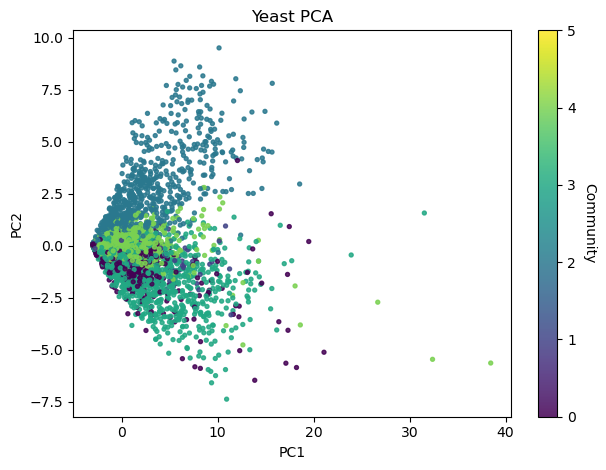

In [49]:
pca_transform(G_yeast, yeast_grps, "Yeast PCA")

Human PCA

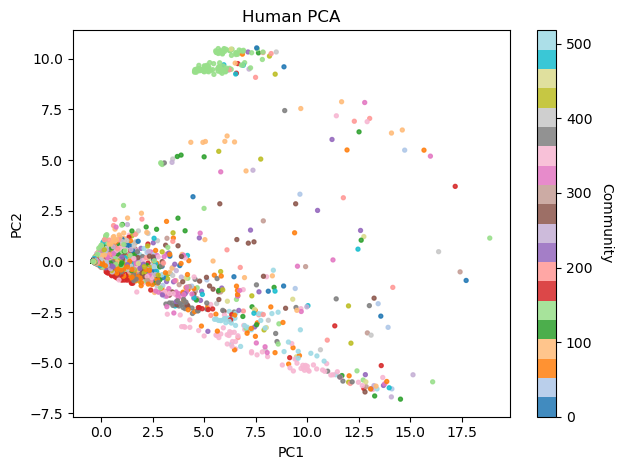

In [42]:
pca_transform(G_human, human_grps, "Human PCA")

Clustering Metrics and Experimentation